<a href="https://colab.research.google.com/github/MarcGaac/Stat-Theory/blob/main/FA_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

data set

In [2]:
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('Invisibility Cloak.csv')

# Split the data into the two independent groups
no_cloak = df[df['Cloak'] == 0]['Mischief']
cloak = df[df['Cloak'] == 1]['Mischief']

print("Data loaded successfully. Here are the descriptive statistics:")
print(f"Without Cloak (N={len(no_cloak)}): Mean = {no_cloak.mean():.2f}, SD = {no_cloak.std():.2f}")
print(f"With Cloak    (N={len(cloak)}): Mean = {cloak.mean():.2f}, SD = {cloak.std():.2f}")

Data loaded successfully. Here are the descriptive statistics:
Without Cloak (N=12): Mean = 3.75, SD = 1.91
With Cloak    (N=12): Mean = 5.00, SD = 1.65


Check Your Assumptions
Assumption A—The dependent variable is continuous.
Mischief (number of mischievous acts) is a continuous/scale measurement. We do not need to write any code to test this; it is an assumption of our study design.

Assumption B—The independent variable contains two independent and categorical groups.
The independent variable is the variable Cloak (0 = no Cloak; 1 = Cloak). Both conditions of this assumption have been met.

Assumption C—The observations are independent.
In the analysis each subject belongs to one group (has a Cloak OR does not have a Cloak). Subjects cannot have both group memberships. This assumption has been confirmed as a result of the study design.

Assumption D—There are no appreciable outliers.
This can be determined through a boxplot inspection.

/tmp/ipykernel_1054/363105998.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cloak', y='Mischief', data=df, palette='Set2')


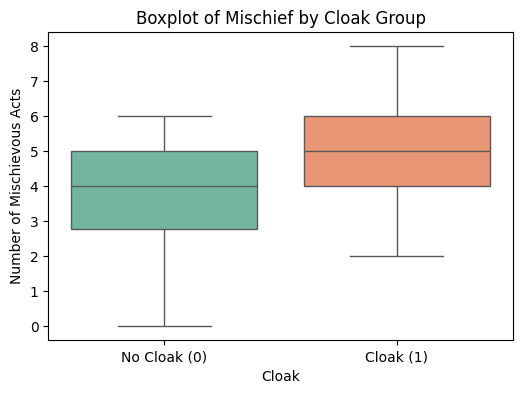

Outliers in 'No Cloak' group: []
Outliers in 'Cloak' group: []


In [3]:
# Create a boxplot to check for outliers
plt.figure(figsize=(6, 4))
sns.boxplot(x='Cloak', y='Mischief', data=df, palette='Set2')
plt.title('Boxplot of Mischief by Cloak Group')
plt.xticks([0, 1], ['No Cloak (0)', 'Cloak (1)'])
plt.ylabel('Number of Mischievous Acts')
plt.show()

# Alternatively, check mathematically using the Interquartile Range (IQR) rule:
def check_outliers(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data < lower_bound) | (data > upper_bound)]

print("Outliers in 'No Cloak' group:", check_outliers(no_cloak).values)
print("Outliers in 'Cloak' group:", check_outliers(cloak).values)

The fifth assumption assumes that the dependent variable is normally distributed for each group. The Shapiro-Wilk Test is applied for evaluating the normality of the distribution of each group; if the p-value of the test is >0.05 then that means the group is normally distributed.

In [4]:
# Shapiro-Wilk test for Normality
stat0, p0 = stats.shapiro(no_cloak)
stat1, p1 = stats.shapiro(cloak)

print(f"Shapiro-Wilk test for 'No Cloak': W = {stat0:.3f}, p = {p0:.3f}")
print(f"Shapiro-Wilk test for 'Cloak':    W = {stat1:.3f}, p = {p1:.3f}")

Shapiro-Wilk test for 'No Cloak': W = 0.913, p = 0.231
Shapiro-Wilk test for 'Cloak':    W = 0.973, p = 0.936


Assumption 6: Homogeneity of variances - (it has been included here to allow for the final calculation). To determine if the variance of the dependent variable is equal across both groups we will use Levene's Test.

In [5]:
# Levene's test for Homogeneity of Variances
stat_lev, p_lev = stats.levene(no_cloak, cloak)
print(f"Levene's test: W = {stat_lev:.3f}, p = {p_lev:.3f}")

Levene's test: W = 0.270, p = 0.609


Standard Student's independent samples t-test.

In [6]:
# Compute the independent samples t-test
t_stat, p_val = stats.ttest_ind(cloak, no_cloak, equal_var=True)

# Calculate degrees of freedom
df_test = len(no_cloak) + len(cloak) - 2

print(f"Independent Samples t-test results:")
print(f"t({df_test}) = {t_stat:.3f}")
print(f"p-value = {p_val:.3f}")

Independent Samples t-test results:
t(22) = 1.713
p-value = 0.101


Results

The number of mischievous acts performed by participants who either possessed or wore an invisibility cloak was examined using a t-test, as well as examining any differences in the two participant groups (ones wearing the invisibility cloak versus ones not wearing it).

Before conducting the t-test, assumptions regarding the data were checked (using boxplots) and found to be met. No extreme outliers were evident in either group of data, and the distribution of the data were approximately normally distributed (using the Shapiro-Wilk test) for each group (i.e., individuals who had or did not have an invisibility cloak - (p > .05)). Homogeneity of variance assumption was also tested and was found to be met (using Levene’s test - (p =.609)).

When compared to the control group, people who wore the invisibility cloak committed more mischief than did the no cloak group (M=5.00; SD=1.65 vs. M=3.75; SD=1.91). This difference, however, was not statistically significant (t(22)=1.71; p=.101) so we accept the null hypothesis and conclude that there's no difference between the two groups with respect to the total number of mischievous acts committed, depending on whether the subject possessed the cloak of invisibility.